### Imports

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
import numpy as np
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr



import sys
sys.path.insert(0, "..")

from model.data.load_data import LoadBaseSatelliteData



In [2]:
%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

### Data loading

---- LOADING FOOTPRINTS
Loading footprint data from /group/chem/acrg/LPDM/fp_NAME_pre20210701/NORTHAFRICA/*SAHARA*NORTHAFRICA_201603*.nc
no sampling was done because you didnt pass a valid sampling mode, or freq=1
Loading 940 footprints

 ---- LOADING MET
Loading meteorology from /group/chem/acrg/met_archive/UM/NORTHAFRICA/NORTHAFRICA_Met_201603*.nc

---- LOADING TOPOG
trying to load topography from /group/chem/acrg/LPDM/topog_NAME/TopogUMG_Mk8_global.nc
---- All done!


In [90]:
"""
Load the footprints for the region and period with the base data object.
Stores the footprints (without cropping) in data.fp_data_full
load_everything=True also loads the original meteorology, without cropping or interpolating, in data.met_file, as well as the topography and landuse in data.topog_file and data.landcover_file, which are interpolated in space to the shape of the footprints
"""
data = LoadBaseSatelliteData(201601, region="BRAZIL", load_everything=True, verbose=True)
#data = LoadBaseSatelliteData(201603, region="SAHARA", load_everything=True, verbose=True)

---- LOADING FOOTPRINTS
Loading footprint data from /group/chem/acrg/LPDM/fp_NAME_pre20210701/SOUTHAMERICA/*BRAZIL*SOUTHAMERICA_201601*.nc
no sampling was done because you didnt pass a valid sampling mode, or freq=1
Loading 1438 footprints

 ---- LOADING MET
Loading meteorology from /group/chem/acrg/met_archive/UM/SOUTHAMERICA/SOUTHAMERICA_Met_201601*.nc

---- LOADING TOPOG
trying to load topography from /group/chem/acrg/LPDM/topog_NAME/TopogUMG_Mk8_global.nc
---- All done!


## Plotting meteorology

In [91]:
data.met_file

<xarray.Dataset>
Dimensions:                              (lat: 357, levels: 20, lon: 239,
                                          time: 744)
Coordinates:
  * lat                                  (lat) float64 -60.98 -60.75 ... 22.32
    sigma                                (levels) float32 dask.array<chunksize=(20,), meta=np.ndarray>
  * levels                               (levels) int32 1 3 6 9 ... 48 51 54 57
    level_height                         (levels) float32 dask.array<chunksize=(20,), meta=np.ndarray>
  * lon                                  (lon) float64 -91.33 -90.98 ... -7.553
  * time                                 (time) datetime64[ns] 2016-01-01 ......
Data variables:
    air_pressure                         (levels, lat, lon, time) float32 dask.array<chunksize=(20, 357, 7, 744), meta=np.ndarray>
    air_pressure_at_sea_level            (lat, lon, time) float32 dask.array<chunksize=(357, 120, 744), meta=np.ndarray>
    air_temperature                      (levels, lat, lon, time) float32 dask.array<chunksize=(20, 357, 7, 744), meta=np.ndarray>
    atmosphere_boundary_layer_thickness  (lat, lon, time) float32 dask.array<chunksize=(357, 120, 744), meta=np.ndarray>
    surface_air_pressure                 (lat, lon, time) float32 dask.array<chunksize=(357, 120, 744), meta=np.ndarray>
    surface_upward_sensible_heat_flux    (lat, lon, time) float32 dask.array<chunksize=(357, 120, 744), meta=np.ndarray>
    upward_air_velocity                  (levels, lat, lon, time) float32 dask.array<chunksize=(20, 357, 7, 744), meta=np.ndarray>
    x_wind                               (levels, lat, lon, time) float32 dask.array<chunksize=(20, 357, 7, 744), meta=np.ndarray>
    y_wind                               (levels, lat, lon, time) float32 dask.array<chunksize=(20, 357, 7, 744), meta=np.ndarray>
Attributes:
    source:           Data from Met Office Unified Model
    author:           Elena Fillola (ef17148)
    created:          2022-11-14 13:11
    transformations:  interpolated linearly in space to NAME resolution, inte...

## Plotting footprints

In [92]:
data.fp_data_full

<xarray.Dataset>
Dimensions:               (time: 1438, lon: 190, lat: 357, lev: 1, height: 20)
Coordinates:
  * time                  (time) datetime64[ns] 2016-01-01T14:59:12.500000 .....
  * lon                   (lon) float32 -91.33 -90.98 -90.62 ... -25.15 -24.8
  * lat                   (lat) float32 -60.98 -60.75 -60.51 ... 22.09 22.32
  * lev                   (lev) |S1 b'c'
  * height                (height) float32 500.0 1.5e+03 ... 1.85e+04 1.95e+04
Data variables:
    fp                    (lat, lon, time) float32 dask.array<chunksize=(357, 190, 1438), meta=np.ndarray>
    temperature           (time) float32 dask.array<chunksize=(1438,), meta=np.ndarray>
    pressure              (time) float32 dask.array<chunksize=(1438,), meta=np.ndarray>
    wind_speed            (time) float32 dask.array<chunksize=(1438,), meta=np.ndarray>
    wind_direction        (time) float32 dask.array<chunksize=(1438,), meta=np.ndarray>
    PBLH                  (time) float32 dask.array<chunksize=(1438,), meta=np.ndarray>
    release_lon           (time) float32 dask.array<chunksize=(1438,), meta=np.ndarray>
    release_lat           (time) float32 dask.array<chunksize=(1438,), meta=np.ndarray>
    particle_locations_n  (height, lon, time) float32 dask.array<chunksize=(20, 190, 1438), meta=np.ndarray>
    particle_locations_e  (height, lat, time) float32 dask.array<chunksize=(20, 357, 1438), meta=np.ndarray>
    particle_locations_s  (height, lon, time) float32 dask.array<chunksize=(20, 190, 1438), meta=np.ndarray>
    particle_locations_w  (height, lat, time) float32 dask.array<chunksize=(20, 357, 1438), meta=np.ndarray>
Attributes:
    max_level:  17
    author:     rt17603
    created:    2019-05-29 20:05:49.874413

## Plotting topography and land use

In [93]:
data.topog_file

<xarray.Dataset>
Dimensions:             (lat: 357, lon: 190)
Coordinates:
  * lat                 (lat) float32 -60.98 -60.75 -60.51 ... 21.85 22.09 22.32
  * lon                 (lon) float32 -91.33 -90.98 -90.62 ... -25.15 -24.8
Data variables:
    surface_altitude    (lat, lon) float32 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    latitude_longitude  int32 -2147483647
Attributes:
    source:       Data from Met Office Unified Model
    um_version:   8.3
    Conventions:  CF-1.7

In [94]:
data.landcover_file

<xarray.Dataset>
Dimensions:             (pseudo_level: 9, lat: 357, lon: 190)
Coordinates:
  * pseudo_level        (pseudo_level) int32 1 2 3 4 5 6 7 8 9
  * lat                 (lat) float32 -60.98 -60.75 -60.51 ... 21.85 22.09 22.32
  * lon                 (lon) float32 -91.33 -90.98 -90.62 ... -25.15 -24.8
Data variables:
    landcover_fraction  (lat, lon, pseudo_level) float32 nan nan nan ... nan nan
    land_binary_mask    (lat, lon) float32 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    landcover_type      (lat, lon) float64 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
Attributes:
    source:      Data from Met Office Unified Model
    um_version:  8.3
    STASH:       [  1   0 216]

## Jeff trying stuff out

### Plot map with bounding box for data

In [95]:
def get_lat_lon_bounds(data, type = "met"):
    """Return a dictionary with the min/max lat/lon bounds from the specified data series (met, fp, or topo)."""
    if type == "met":
        lat_met = data.met_file["lat"].values
        lon_met = data.met_file["lon"].values
    elif type == "fp":
        lat_met = data.fp_data_full["lat"].values
        lon_met = data.fp_data_full["lon"].values
    elif type == "topo":
        lat_met = data.topog_file["lat"].values
        lon_met = data.topog_file["lon"].values
    return dict(
        min_lat=float(np.min(lat_met)),
        max_lat=float(np.max(lat_met)),
        min_lon=float(np.min(lon_met)),
        max_lon=float(np.max(lon_met)),
    )

def rectangle_segments(min_lon, max_lon, min_lat, max_lat, wrap_center=0):
    """
    Return 1 or 2 polygons (lon, lat) for a rectangle, splitting if it crosses the anti-meridian.
    """
    # To cover case where min_lon > max_lon due to anti-meridian crossing (ie near New Zealand / Alaska), we split into two segments
    if max_lon < min_lon:
        segA = [
            (min_lon, min_lat), (wrap_center+180, min_lat),
            (wrap_center+180, max_lat), (min_lon, max_lat)
        ]
        segB = [
            (wrap_center-180, min_lat), (max_lon, min_lat),
            (max_lon, max_lat), (wrap_center-180, max_lat)
        ]
        return [segA, segB]
    else:
        return [[(min_lon, min_lat), (max_lon, min_lat), (max_lon, max_lat), (min_lon, max_lat)]]

def add_lonlat_rectangle(ax, min_lon, max_lon, min_lat, max_lat,
                         edgecolor='tab:blue', facecolor='none', linewidth=2.2,
                         zorder=5, wrap_center=0, crs=ccrs.PlateCarree(), label=None):
    polys = rectangle_segments(min_lon, max_lon, min_lat, max_lat, wrap_center=wrap_center)
    first = True
    for poly in polys:
        patch = Polygon(np.array(poly), closed=True,
                        edgecolor=edgecolor, facecolor=facecolor, linewidth=linewidth,
                        zorder=zorder, transform=crs,
                        label=label if first and label else None)
        ax.add_patch(patch)
        first = False

def plot_domain(data, type, 
                  projection="PlateCarree",  # "PlateCarree" or "Robinson" etc.
                  wrap_center=0,
                  zoom_to_data=True,
                  title="UM Meteorology Domain"):
    """Plot the bounding rectangle from the provided `data` container."""
    # 1) Get bounds from helper
    met_bounds = get_lat_lon_bounds(data, type)

    # 2) Choose projection
    proj_map = {
        "PlateCarree": ccrs.PlateCarree(),
        "Robinson": ccrs.Robinson(),
        "Mollweide": ccrs.Mollweide(),
        "Mercator": ccrs.Mercator(),
        "LambertConformal": ccrs.LambertConformal(),
    }.get(projection, ccrs.PlateCarree())

    # 3) Base map
    fig = plt.figure(figsize=(10, 6))
    ax = plt.axes(projection=proj_map)
    ax.set_global()
    ax.coastlines(linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4)
    ax.gridlines(draw_labels=False, linewidth=0.4, color='gray', alpha=0.5, linestyle='--')

    # 4) Draw the Met rectangle
    add_lonlat_rectangle(ax,
                         met_bounds["min_lon"], met_bounds["max_lon"],
                         met_bounds["min_lat"], met_bounds["max_lat"],
                         edgecolor='tab:blue', linewidth=2.2, label=f'{type} domain',
                         wrap_center=wrap_center)

    # 5) Legend
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend(loc='lower left', frameon=True)

    # 6) Optional zoom to Met extent (only if it doesn't cross anti-meridian near NZ)
    if zoom_to_data:
        min_lon, max_lon = met_bounds["min_lon"], met_bounds["max_lon"]
        min_lat, max_lat = met_bounds["min_lat"], met_bounds["max_lat"]
        if max_lon >= min_lon:  # no anti-meridian crossing
            ax.set_extent([min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree())

    plt.title(title, pad=10)
    plt.tight_layout()
    return fig, ax

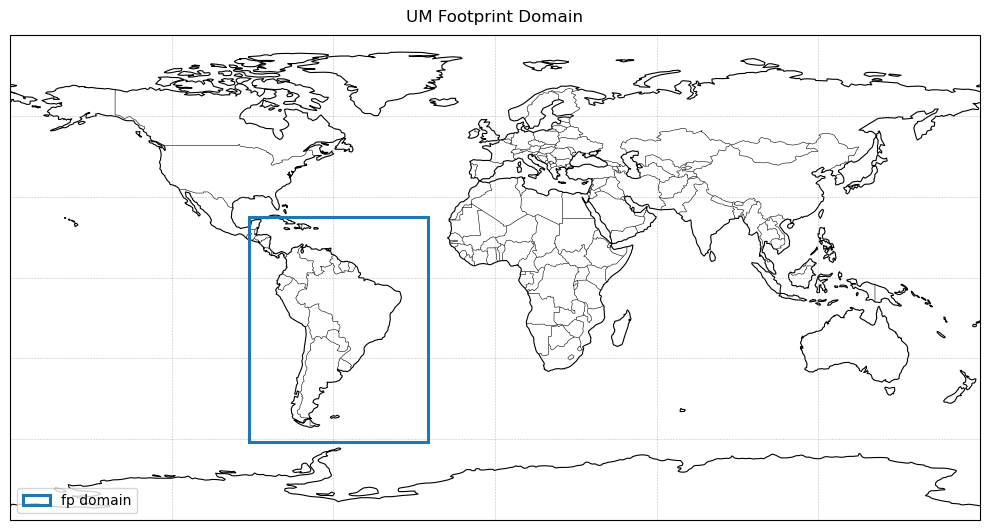

In [96]:
fig, ax = plot_domain(
    data, "fp",
    projection="PlateCarree",  # "PlateCarree" gives a true lon/lat view; "Robinson" for global context
    zoom_to_data=False,
    title="UM Footprint Domain"
)
plt.show()

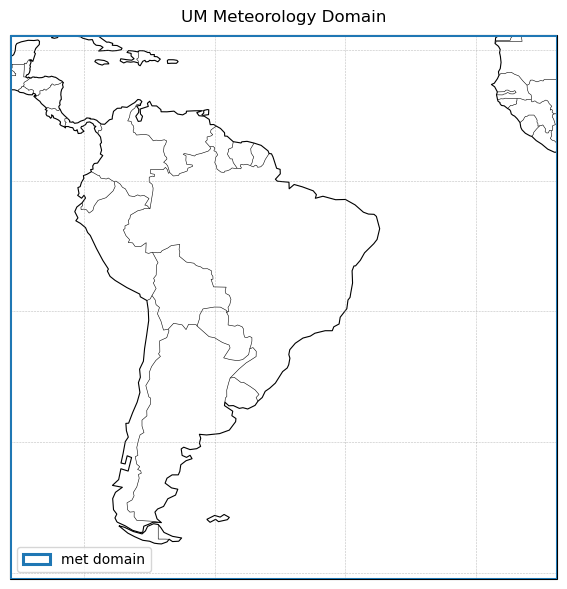

In [97]:
# Can also constrain to only showing the met domain
fig, ax = plot_domain(
    data, "met",
    projection="PlateCarree",  # "PlateCarree" gives a true lon/lat view; "Robinson" for global context
    zoom_to_data=True,
    title="UM Meteorology Domain"
)
plt.show()

### Plot topo

In [98]:
def plot_topography(
    data,
    cmap='RdYlGn_r',
    n_bins=10,
    vmin=None,
    vmax=None,
    plot_country_boundaries=True,
    ocean_colour="#1d9cfe",
    land_only=True,
    figure_size=(10.5, 5),
):
    """
    Plot topography (surface altitude), with:
      - oceans in a fixed colour (not part of the colour scale), and
      - a discrete colour scale with `n_bins` bins.

    Parameters
    ----------
    data : LoadBaseSatelliteData
        Container with topography dataset in `data.topog_file`, variable 'surface_altitude' (lat, lon).
        If available, a land mask is read from `data.landcover_file['land_binary_mask']` and used in "land_only" masking.
    cmap : str, optional
        Base colormap name to discretize. Default 'RdYlGn_r', other options include 'terrain'.
    n_bins : int, optional
        Number of discrete bins. Default 10.
    vmin, vmax : float or None
        Optional min/max (in metres) for bin edges. If None, inferred from land-only finite values.
    plot_country_boundaries : bool, optional
        Overlay country boundaries. Default True.
    ocean_colour : str, optional
        Colour for oceans (not included in colourbar). Default blue.
    land_only : bool, optional
        If True, only include land points (mask out ocean points).
        Default is True.
    figure_size : tuple, optional
        Figure size in inches.

    Returns
    -------
    fig, ax : matplotlib Figure and Axes
    mesh : QuadMesh
        The pcolormesh artist.
    (bin_edges) : np.ndarray
        The bin edges used for the discrete colour mapping.
    """

    ds = data.topog_file
    da = ds['surface_altitude']  # (lat, lon)

    # Keep only finite numeric values
    da = da.where(np.isfinite(da))
    Z = da.values  # 2D array


    # Apply optional mask (keep True, drop False)
    if land_only:
        # Use land mask (True=land, False=ocean)
        land_mask = (data.landcover_file['land_binary_mask'] > 0.9)
        da = da.where(land_mask)

    # Compute bin edges
    Z_land = da.values
    Z_land_flat = Z_land[np.isfinite(Z_land)]
    if Z_land_flat.size == 0:
        raise ValueError("No valid land altitude values found after masking/cleaning.")

    # Set bin edges
    lo = np.min(Z_land_flat) if vmin is None else float(vmin)
    hi = np.max(Z_land_flat) if vmax is None else float(vmax)
    if not np.isfinite(lo) or not np.isfinite(hi) or lo >= hi:
        raise ValueError("Invalid vmin/vmax or data range for discrete binning.")

    bin_edges = np.linspace(lo, hi, n_bins + 1)

    # Build a discrete colormap from the base cmap
    base_cmap = plt.get_cmap(cmap)
    # Sample at bin centers to get n distinct colours
    centers = (bin_edges[:-1] + bin_edges[1:]) / 2.0
    centers01 = (centers - lo) / (hi - lo + 1e-15)
    colours = base_cmap(centers01)
    discrete_cmap = ListedColormap(colours, name=f"{cmap}_{n_bins}bins")

    # Make sure masked (ocean) cells use a fixed colour that is NOT part of the colour scale
    discrete_cmap.set_bad(ocean_colour)

    # Discrete normalization
    norm = BoundaryNorm(bin_edges, ncolors=discrete_cmap.N, clip=True)

    lon = ds['lon'].values
    lat = ds['lat'].values

    # --- Plot ---
    fig = plt.figure(figsize=figure_size)
    proj = ccrs.PlateCarree()
    ax = plt.axes(projection=proj)

    # Background features
    ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
    if plot_country_boundaries:
        ax.add_feature(cfeature.BORDERS, linewidth=0.7, edgecolor="black", alpha=0.7)

    gl = ax.gridlines(draw_labels=True, x_inline=False, y_inline=False,
                      linewidth=0.3, color='0.5', alpha=0.6)

    # pcolormesh with discrete colors and masked oceans
    mesh = ax.pcolormesh(
        lon, lat, da.values,
        transform=proj,
        cmap=discrete_cmap,
        norm=norm,
        shading='auto'
    )

    # Colourbar: show only land scale (oceans are masked and not shown in the bar)
    cb = plt.colorbar(
        mesh, ax=ax, orientation='horizontal', pad=0.06, shrink=0.85,
        boundaries=bin_edges,
        ticks=centers
    )

    # Labels for the colourbar
    units = da.attrs.get('units', 'm')
    long_name = da.attrs.get('long_name', 'Surface altitude')
    cb.set_label(f"{long_name} [{units}]")

    # Optionally format tick labels (e.g., integers for metres)
    try:
        cb.ax.set_xticklabels([f"{v:.0f}" for v in centers])
    except Exception:
        pass

    # Title & layout
    ax.set_title(long_name if long_name else 'Topography')
    plt.tight_layout()
    plt.show()

    return fig, ax, mesh, bin_edges

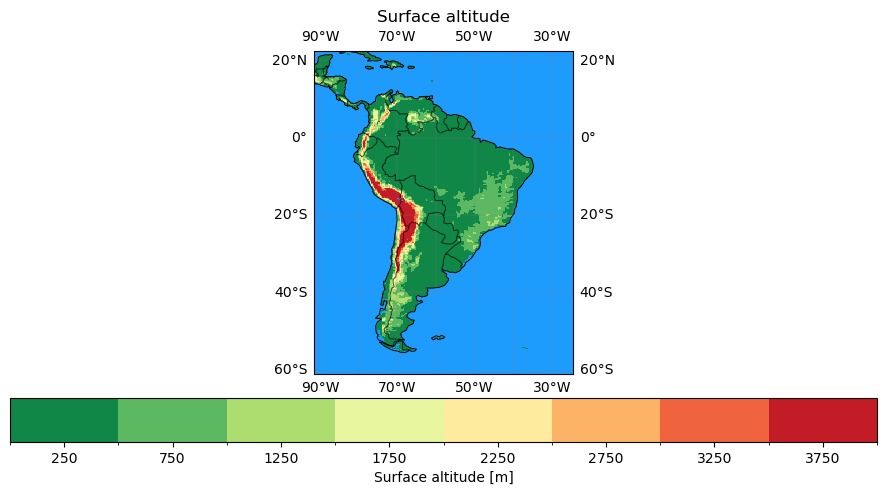

In [99]:
fig, ax, mesh, edges = plot_topography(
    data,
    n_bins=8,
    vmin=0, vmax=4000, # Max altitude in metres
    plot_country_boundaries=True
)

### Histogram of topography

In [100]:
def plot_topography_histogram(
    data,
    bins=50,
    range=None,
    density=False,
    cumulative=False,
    land_only=True,
    title=None,
    figsize=(8, 5),
    colour="#4C78A8",
    alpha=0.8,
    edgecolour='white',
    log_y=False
):
    """
    Create a histogram of topography (surface altitude) values from `data.topog_file`.

    Parameters
    ----------
    data : LoadBaseSatelliteData
        Container with the topography dataset in `data.topog_file`.
        Must contain variable 'surface_altitude' with dims (lat, lon).
    bins : int or sequence, optional
        Number of bins or explicit bin edges. Default is 50.
    range : tuple(float, float) or None
        Lower/upper range of the bins, e.g., (0, 5000) metres. If None, inferred from data. 
    density : bool, optional
        If True, plot probability density (area under histogram = 1).
        If False, plot raw counts. Default False.
    cumulative : bool, optional
        If True, plot cumulative histogram. Default False.
    land_only : bool, optional
        If True, only include land points (mask out ocean points).
        Default is True.
    title : str or None
        Custom title. If None, uses the variable long_name.
    figsize : tuple
        Figure size in inches. Default (8, 5).
    colour : str
        Bar colour. Default '#4C78A8'.
    alpha : float
        Bar transparency. Default 0.8.
    edgecolour : str
        Bar edge colour. Default 'white'.
    log_y : bool
        If True, use a logarithmic y-axis. Useful when the distribution spans orders of magnitude.

    Returns
    -------
    fig, ax : matplotlib Figure, Axes
        Figure and axes of the histogram.
    (counts, bin_edges) : tuple(np.ndarray, np.ndarray)
        The histogram values returned by matplotlib (counts or density) and the bin edges.
    """

    ds = data.topog_file
    da = ds['surface_altitude']  # (lat, lon)

    # Ensure finite values only
    da = da.where(np.isfinite(da))

    # Apply optional mask (keep True, drop False)
    if land_only:
        land_mask = (data.landcover_file['land_binary_mask'] > 0.9)
        da = da.where(land_mask)
    Z = da.values.ravel()
    Z = Z[np.isfinite(Z)]  # remove NaN after ravel

    if Z.size == 0:
        raise ValueError("No valid altitude values found after masking/cleaning.")

    # Units and name (fallbacks)
    units = da.attrs.get('units', 'm')
    long_name = da.attrs.get('long_name', 'Surface altitude')

    # Build histogram
    fig, ax = plt.subplots(figsize=figsize)

    counts, bin_edges, patches = ax.hist(
        Z,
        bins=bins,
        range=range,
        density=density,
        cumulative=cumulative,
        color=colour,
        alpha=alpha,
        edgecolor=edgecolour
    )

    # Labels & title
    if density:
        y_label = 'Density'
    else:
        y_label = 'Cumulative count' if cumulative else 'Count'

    if log_y:
        ax.set_yscale('log')
        # Ensure a positive lower bound (hist may have zeros)
        positive = counts[counts > 0]
        if positive.size > 0:
            ymin = max(positive.min() * 0.5, 1e-2 if density else 1.0)
            # keep current top if already set by Matplotlib; otherwise set a sensible top
            ytop = ax.get_ylim()[1]
            ax.set_ylim(bottom=ymin, top=ytop)
        # Clarify label
        y_label += ' (log scale)'

    ax.set_xlabel(f"{long_name} [{units}]")
    ax.set_ylabel(y_label)
    ax.set_title(title if title else f"Histogram of {long_name}")

    # Grid and layout
    ax.grid(True, which='both', linestyle=':', linewidth=0.6, alpha=0.7)
    plt.tight_layout()
    plt.show()

    return fig, ax, (counts, bin_edges)

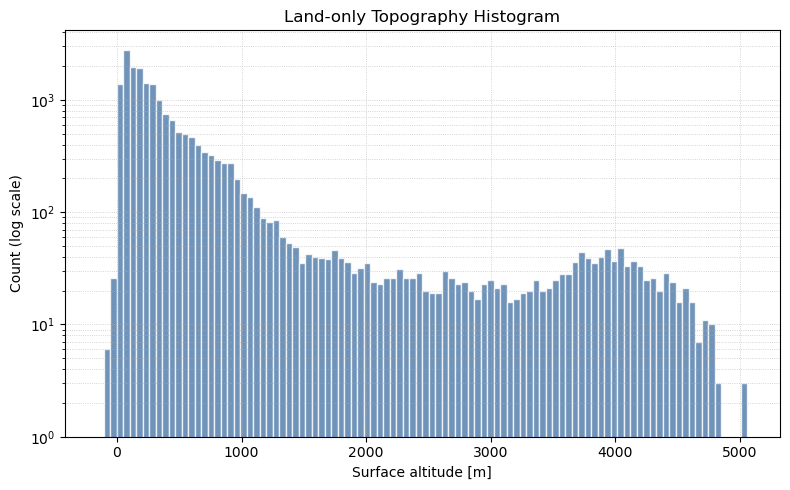

In [101]:
fig, ax, _ = plot_topography_histogram(
    data,
    bins=100, #Or can be eg np.arange(-500, 6000, 100)
    log_y=True,
    density=False,
    title="Land-only Topography Histogram"
)

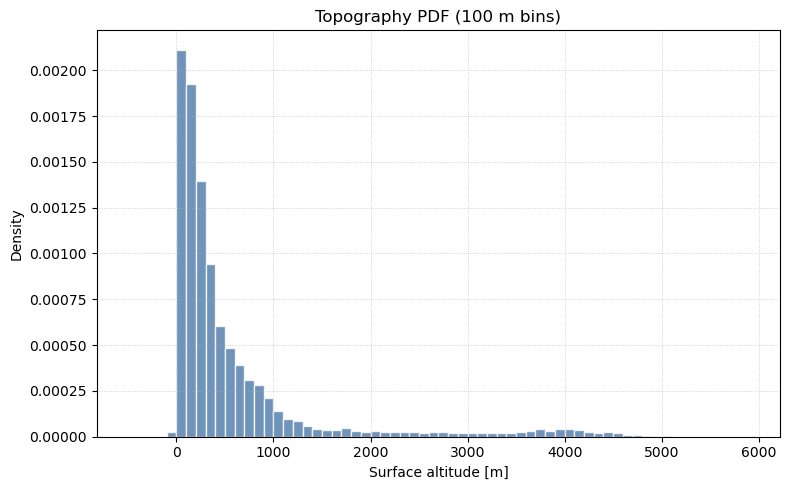

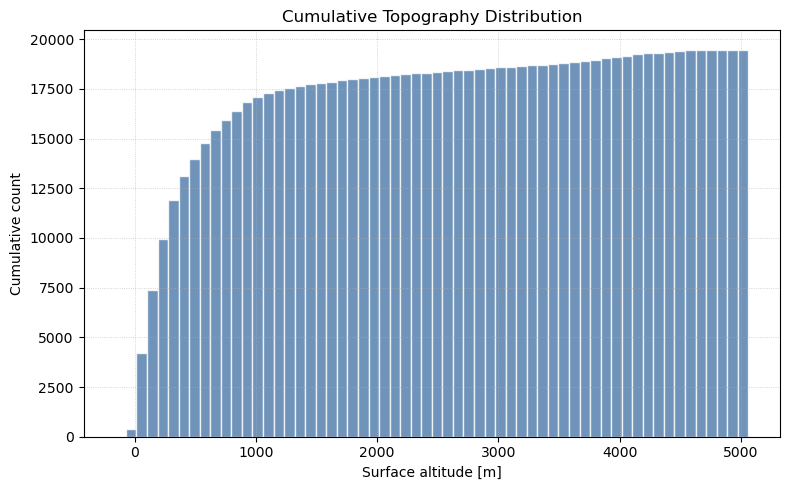

In [102]:
# Two more examples: 
# Probability density function
fig, ax, _ = plot_topography_histogram(
    data,
    bins=np.arange(-500, 6000, 100),
    density=True,
    title="Topography PDF (100 m bins)"
)

# Cumulative distribution function
fig, ax, _ = plot_topography_histogram(
    data,
    bins=60,
    cumulative=True,
    title="Cumulative Topography Distribution"
)

### Land-use

In [103]:
def plot_landuse_frequency(
    data,
    outfile=None,
    log_y=False,
    area_weighted=False,
    as_percent=True,
):
    """
    Plot a bar chart showing the total fractional area for each land-use class.

    Parameters
    ----------
    data : object
        Container with `data.landcover_file['landcover_fraction']`.
        Expected dims: (lat, lon, pseudo_level) or (pseudo_level, lat, lon).
        Ocean/invalid grid cells are typically NaN and are ignored by the sum.
    outfile : str or None
        If provided, saves the figure to this filepath.
    log_y : bool
        If True, use a logarithmic y-axis.
        Default is False (linear scale).
    area_weighted : bool
        If True, weight each grid cell by cos(latitude) before summation (equal-area approx).
        Default is False (simple sum of fractions).
    as_percent : bool
        If True, convert totals to percentage of the total fractional area over all classes.
        Default is True (plot share of each class rather than raw totals).

    Returns
    -------
    fig, ax : Matplotlib Figure and Axes
    freq : dict
        Mapping {class_id: total} for the plotted classes.
    """

    # Class labels (0 included only for completeness)
    CLASS_LABELS = {
        0: "sea",
        1: "broadleaf trees",
        2: "needleleaf trees",
        3: "C3 (temperate) grass",
        4: "C4 (tropical) grass",
        5: "shrubs",
        6: "urban",
        7: "inland water",
        8: "bare soil",
        9: "ice",
    }

    DEFAULT_COLOURS = {
        0:  "#8ecae6",  # sea (light blue)
        1:  "#2ca02c",  # broadleaf trees (green)
        2:  "#1f7a1f",  # needleleaf trees (dark green)
        3:  "#8fd175",  # C3 grass
        4:  "#ffd166",  # C4 grass
        5:  "#b38f5a",  # shrubs
        6:  "#7f7f7f",  # urban
        7:  "#2ca8c2",  # inland water
        8:  "#d2b48c",  # bare soil
        9:  "#a0c4ff",  # ice
    }

    da = data.landcover_file['landcover_fraction']

    # Normalise dims to (lat, lon, pseudo_level)
    if da.dims == ('pseudo_level', 'lat', 'lon'):
        da = da.transpose('lat', 'lon', 'pseudo_level')
    elif da.dims != ('lat', 'lon', 'pseudo_level'):
        raise ValueError(f"Unexpected dims {da.dims}. Expected (lat, lon, pseudo_level).")

    class_ids = [int(c) for c in da['pseudo_level'].values.tolist()]  # typically 1..9

    # Optional area weights - takes into account the convergence of meridians
    # at high/low latitudes for a more accurate global summary (not just a simple sum of fractions)
    weights = None
    if area_weighted:
        lat = da['lat'].values
        cosw = np.cos(np.deg2rad(lat))
        weights2d = xr.DataArray(
            np.repeat(cosw[:, None], da.sizes['lon'], axis=1),
            coords={'lat': da['lat'], 'lon': da['lon']},
            dims=('lat', 'lon')
        )
        weights = weights2d.broadcast_like(da)

    # Sum over lat/lon, ignoring NaN (ocean)
    if weights is None:
        summed = da.sum(dim=('lat', 'lon'), skipna=True)
    else:
        summed = (da * weights).sum(dim=('lat', 'lon'), skipna=True)

    totals = np.array(summed.values, dtype=float)

    freq_all = {cid: totals[i] for i, cid in enumerate(class_ids)}
    freq_all = {cid: v for cid, v in freq_all.items() if np.isfinite(v)}

    # Convert to % if requested
    if as_percent:
        total_sum = np.sum(list(freq_all.values()))
        if total_sum > 0:
            freq_all = {cid: (v / total_sum) * 100.0 for cid, v in freq_all.items()}

    # Sorted plotting order
    plot_ids = sorted(freq_all.keys())
    labels = [CLASS_LABELS[cid] for cid in plot_ids]
    values = [freq_all[cid] for cid in plot_ids]
    bar_colors = [DEFAULT_COLOURS.get(cid, "steelblue") for cid in plot_ids]

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(9, 4.8))
    x = np.arange(len(plot_ids))
    ax.bar(x, values, color=bar_colors, edgecolor='black')

    if as_percent:
        y_label = "Share of fractional landcover (%)"
    else:
        y_label = "Total fractional landcover"

    if area_weighted:
        y_label += " (area-weighted)"
    if log_y:
        ax.set_yscale('log')
        y_label += " (log scale)"

    ax.set_ylabel(y_label)
    ax.set_title("Land-use frequency (sum of fractions per class)")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha='right')
    ax.grid(True, axis='y', linestyle=':', linewidth=0.6, alpha=0.7)

    plt.tight_layout()

    if outfile:
        plt.savefig(outfile, bbox_inches='tight')
        print(f"Saved land-use bar chart to: {outfile}")

    plt.show()

    return fig, ax, freq_all

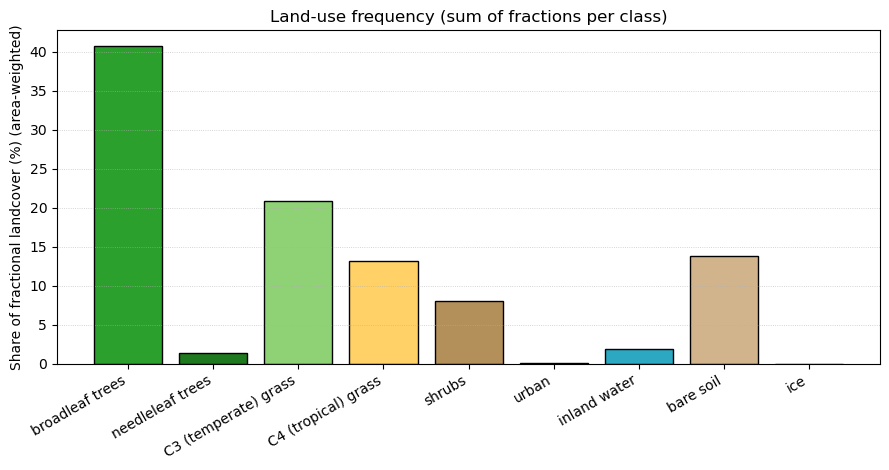

In [104]:
fig, ax, freq = plot_landuse_frequency(data,
                                        area_weighted=True,
                                       )

In [ ]:
def plot_majority_landuse_map(
    data,
    figure_size=(10.5, 5),
    plot_country_boundaries=True,
    coastline=True,
    title="Majority land‑use class",
    show_legend=True,
    legend_loc="lower left",
):
    """
    Plot a spatial map of the majority land‑use class for each grid cell,
    using `data.landcover_file['landcover_fraction']`.

    Rules
    -----
    - Majority class = argmax over `pseudo_level` of landcover_fraction.
    - Cells where all classes are NaN are treated as `sea` (class 0).

    Parameters
    ----------
    data : object
        Container with `data.landcover_file['landcover_fraction']`.
        Expected dims: (lat, lon, pseudo_level) or (pseudo_level, lat, lon).
    figure_size : tuple
        Figure size in inches.
    plot_country_boundaries : bool
        If True, overlay country boundaries.
        Default to True.
    coastline : bool
        If True, overlay a coastline.
    title : str
        Plot title.
    show_legend : bool
        If True, show a categorical legend for classes present in the domain.
    legend_loc : str
        Matplotlib legend location string.

    Returns
    -------
    fig, ax, mesh, majority_da, (cmap, norm)
        - fig, ax: Matplotlib Figure and Axes
        - mesh: QuadMesh artist from pcolormesh
        - majority_da: xarray.DataArray of integer class IDs (0..9)
        - (cmap, norm): the discrete colormap and normaliser used
    """

    # --- Class labels & fixed colours (UK English spelling) ---
    CLASS_LABELS = {
        0: "sea",
        1: "broadleaf trees",
        2: "needleleaf trees",
        3: "C3 (temperate) grass",
        4: "C4 (tropical) grass",
        5: "shrubs",
        6: "urban",
        7: "inland water",
        8: "bare soil",
        9: "ice",
    }

    CLASS_COLOURS = {
        0:  "#1d9cfe",  # sea (light blue)
        1:  "#2ca02c",  # broadleaf trees (green)
        2:  "#1f7a1f",  # needleleaf trees (dark green)
        3:  "#8fd175",  # C3 grass (light green)
        4:  "#ffd166",  # C4 grass (yellow-ish)
        5:  "#b38f5a",  # shrubs (brown)
        6:  "#7f7f7f",  # urban (grey)
        7:  "#2ca8c2",  # inland water (cyan)
        8:  "#d2b48c",  # bare soil (tan)
        9:  "#a0c4ff",  # ice (pale blue)
    }

    # --- Load and normalise dims ---
    da = data.landcover_file['landcover_fraction']
    if da.dims == ('pseudo_level', 'lat', 'lon'):
        da = da.transpose('lat', 'lon', 'pseudo_level')
    elif da.dims != ('lat', 'lon', 'pseudo_level'):
        raise ValueError(f"Unexpected dims {da.dims}. Expected (lat, lon, pseudo_level).")

    # Grid coords
    lon = da['lon'].values
    lat = da['lat'].values

    # Identify cells with any finite class value (land or inland water, etc.)
    valid = np.isfinite(da).any(dim='pseudo_level')  # (lat, lon) boolean

    # Compute majority class on valid cells:
    # Fill NaNs with a very negative number so they never win argmax,
    # but *only* use this for argmax (not for plotting actual fractions).
    filled = da.fillna(-1e15)
    # argmax gives positional indices 0..(n_classes-1)
    idx = filled.argmax(dim='pseudo_level')  # (lat, lon), dtype=int
    # Map positional indices to actual pseudo_level IDs (typically 1..9)
    pseudo_ids = da['pseudo_level']
    majority_da = pseudo_ids.isel(pseudo_level=idx)  # (lat, lon), values in 1..9

    # Assign sea=0 where no class is present (all-NaN originally)
    majority_da = xr.where(valid, majority_da, 0).astype(int)

    # --- Build discrete colormap & norm for classes 0-9 ---
    ordered_ids = list(range(0, 10))
    colours_list = [CLASS_COLOURS[i] for i in ordered_ids]
    cmap = ListedColormap(colours_list, name="landuse_maj_0to9")
    # Boundaries at half-integers to capture exact integer values
    boundaries = np.arange(-0.5, 10.5, 1.0)
    norm = BoundaryNorm(boundaries, ncolors=cmap.N, clip=False)

    # --- Plot ---
    fig = plt.figure(figsize=figure_size)
    proj = ccrs.PlateCarree()
    ax = plt.axes(projection=proj)

    if coastline:
        ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
    if plot_country_boundaries:
        ax.add_feature(cfeature.BORDERS, linewidth=0.7, edgecolor="black", alpha=0.7)

    gl = ax.gridlines(draw_labels=True, x_inline=False, y_inline=False,
                      linewidth=0.3, color='0.5', alpha=0.6)

    mesh = ax.pcolormesh(
        lon, lat, majority_da.values,
        transform=proj,
        cmap=cmap,
        norm=norm,
        shading='nearest'  # categorical look; avoids smoothing between classes
    )

    ax.set_title(title)

    # --- Legend (categorical) ---
    if show_legend:
        # Only show classes that actually occur in the domain
        present_ids = np.unique(majority_da.values[np.isfinite(majority_da.values)])
        present_ids = [int(i) for i in present_ids if 0 <= i <= 9]

        handles = [
            Patch(facecolor=CLASS_COLOURS[i], edgecolor='black', label=CLASS_LABELS[i])
            for i in present_ids
        ]
        leg = ax.legend(
            handles=handles,
            loc=legend_loc,
            frameon=True,
            framealpha=0.9,
            fontsize=9,
            title="Majority land‑use"
        )
        leg._legend_box.align = "left"

    plt.tight_layout()
    plt.show()

    return fig, ax, mesh, majority_da, (cmap, norm)

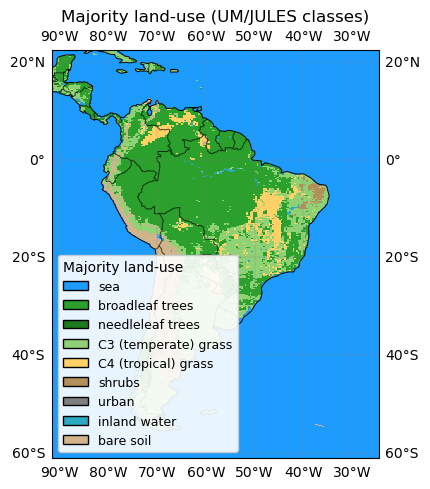

In [107]:
fig, ax, mesh, majority, (cmap, norm) = plot_majority_landuse_map(
    data,
    title="Majority land‑use (UM/JULES classes)"
)

In [ ]:
# To do
# Consolidate land-use labels and colours to a single source (eg yaml, dictionary), used by both the frequency bar chart and the majority map.
# Move land-use spatial map legend off chart, put on right or bottom